# Sunrise Social Club: Predictive Modeling

**Objective:** Predict beverage demand to support inventory planning and event preparation.

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [95]:
df=pd.read_csv("../data/processed/sales_merged.csv")
drink_df = df[df["Item"].isin(["Matcha Latte", "Cold Brew", "Lemonade"])]

In [96]:
model_df = (
    drink_df.groupby(
        ["Date", "Item", "Flavor", "Location", "Event_Type", "Avg_Temp"]
    )["Qty"]
    .sum()
    .reset_index()
)

In [97]:
model_df.head()

,Date,Item,Flavor,Location,Event_Type,Avg_Temp,Qty
0,2026-05-23,Matcha Latte,Salted Maple,Commercial Kitchen,Popup,77,11.0
1,2026-05-23,Matcha Latte,Strawberry,Commercial Kitchen,Popup,77,31.0
2,2026-05-30,Cold Brew,Blueberry,Manteo,Market,79,6.0
3,2026-05-30,Cold Brew,Cake Batter,Manteo,Market,79,9.0
4,2026-05-30,Cold Brew,Salted Maple,Manteo,Market,79,13.0


In [98]:
model_df["Date"] = pd.to_datetime(model_df["Date"])

model_df["Day_of_Week"] = model_df["Date"].dt.day_name()
model_df["Month"] = model_df["Date"].dt.month
model_df["Weekend"] = model_df["Date"].dt.dayofweek >= 5

In [99]:
model_df = model_df.drop(columns=["Date"])

In [100]:
X = model_df.drop(columns=["Qty"])
y = model_df["Qty"]

In [101]:
X=pd.get_dummies(X,drop_first=True)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
baseline_pred=np.full_like(y_test, y_train.mean())

In [104]:
mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base=root_mean_squared_error(y_test, baseline_pred)

In [105]:
lr=LinearRegression()
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)

In [106]:
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = root_mean_squared_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

In [107]:
rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf=rf.predict(X_test)

In [108]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = root_mean_squared_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

In [109]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        mae_base,
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_base,
        rmse_lr,
        rmse_rf
    ]
})

results

,Model,MAE,RMSE
0,Baseline,7.371053,9.806797
1,Linear Regression,5.236082,6.535046
2,Random Forest,3.725000,4.615230


In [110]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

Flavor_Strawberry       0.243486
Item_Matcha Latte       0.171780
Avg_Temp                0.152673
Item_Lemonade           0.074586
Flavor_Salted Maple     0.052078
Day_of_Week_Saturday    0.037637
Event_Type_Market       0.028058
Month                   0.022779
Location_Manteo         0.022616
Flavor_Blueberry        0.022552
dtype: float64

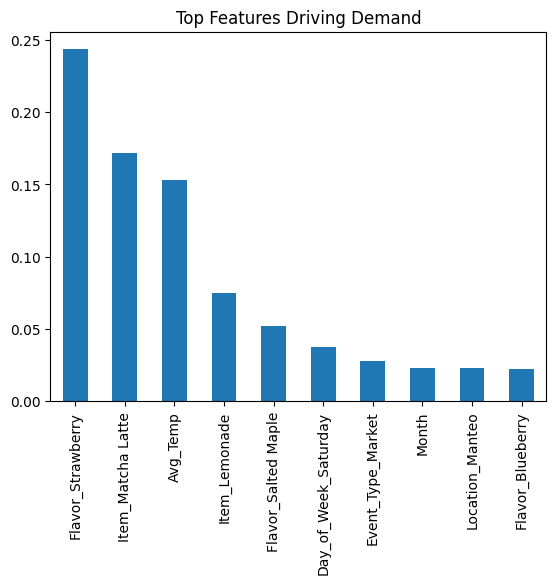

In [111]:
importances.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features Driving Demand")
plt.show()

In [112]:
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_rf
})

results_df.head(10)

,Actual,Predicted
80,33.0,26.64
77,7.0,6.36
73,7.0,6.44
94,30.0,31.70
33,5.0,6.98
79,3.0,9.40
69,13.0,6.09
42,1.0,3.77
0,11.0,8.90
10,20.0,8.32


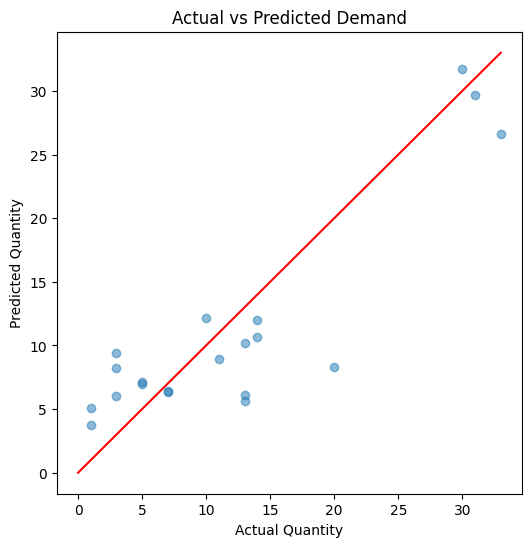

In [113]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Demand")
plt.plot([0, max(y_test)], [0, max(y_test)], color="red")
plt.show()

In [114]:
def build_input_grid(location, event_type, avg_temp, day_of_week, month):
    
    items = ["Matcha Latte", "Cold Brew", "Lemonade"]
    flavors = drink_df["Flavor"].unique()

    rows = []

    for item in items:
        for flavor in flavors:
            rows.append({
                "Item": item,
                "Flavor": flavor,
                "Location": location,
                "Event_Type": event_type,
                "Avg_Temp": avg_temp,
                "Day_of_Week": day_of_week,
                "Month": month,
                "Weekend": day_of_week in ["Saturday", "Sunday"]
            })

    return pd.DataFrame(rows)

In [115]:
def preprocess_input(df_input, trained_columns):
    
    df_encoded = pd.get_dummies(df_input)

    # align with training columns
    df_encoded = df_encoded.reindex(columns=trained_columns, fill_value=0)

    return df_encoded

In [116]:
def predict_demand(location, event_type, avg_temp, day_of_week, month):

    # step 1: build all drink/flavor combos
    input_df = build_input_grid(location, event_type, avg_temp, day_of_week, month)

    # step 2: encode
    input_encoded = preprocess_input(input_df, X.columns)

    # step 3: predict
    input_df["Predicted_Qty"] = rf.predict(input_encoded)

    # step 4: clean output
    return input_df[["Item", "Flavor", "Predicted_Qty"]]

In [117]:
predict_demand(
    location="Manteo",
    event_type="Market",
    avg_temp=85,
    day_of_week="Saturday",
    month=6
)

,Item,Flavor,Predicted_Qty
0,Matcha Latte,Strawberry,29.66
1,Matcha Latte,Vanilla,6.36
2,Matcha Latte,"Strawberry, Blueberry",8.26
3,Matcha Latte,Banana,8.38
4,Matcha Latte,Blueberry,12.18
5,Matcha Latte,Cinn Roll,8.53
6,Matcha Latte,NaN,8.38
7,Matcha Latte,Salted Maple,8.32
8,Matcha Latte,No Syrup,7.14
9,Matcha Latte,Cake Batter,11.80


In [118]:
results = predict_demand("Manteo", "Market", 85, "Saturday", 6)

results.groupby("Item")["Predicted_Qty"].sum()

Item
Cold Brew       107.97
Lemonade         71.31
Matcha Latte    109.01
Name: Predicted_Qty, dtype: float64

In [119]:
results = predict_demand("Manteo", "Market", 85, "Saturday", 6)

results.groupby("Flavor")["Predicted_Qty"].sum()

Flavor
Banana                   23.53
Blueberry                25.68
Cake Batter              30.28
Cinn Roll                29.03
No Syrup                 21.74
Salted Maple             26.22
Strawberry               65.44
Strawberry, Blueberry    22.46
Vanilla                  20.38
Name: Predicted_Qty, dtype: float64